# Stacking Classifier for CVD Prediction

This notebook implements a stacking ensemble classifier:
- **Training Data**: Dataset_B_80_plus_C.csv (56,138 samples)
- **Test Data**: Training_For_Meta_Model.csv (13,653 samples)
- **Base Models**: LightGBM, XGBoost, Random Forest, Logistic Regression
- **Meta Model**: Logistic Regression or Neural Network

## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

# Base Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb

# Meta Model
from sklearn.ensemble import StackingClassifier

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Datasets

In [2]:
# Load training dataset
train_df = pd.read_csv('solo_gbm_dataset/Dataset_B_80_plus_C.csv')
print(f"Training data shape: {train_df.shape}")
print(f"\nTraining data columns: {train_df.columns.tolist()}")

# Load test dataset
test_df = pd.read_csv('Meta Model Dataset/Training_For_Meta_Model.csv')
print(f"\nTest data shape: {test_df.shape}")
print(f"Test data columns: {test_df.columns.tolist()}")

# Display basic info
print("\n" + "="*50)
print("Training Data Info:")
print(train_df.head())

Training data shape: (56137, 11)

Training data columns: ['Age', 'Gender', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Cholesterol Level', 'Glucose Level', 'Smoking Status', 'Alcohol Intake', 'Physical Activity', 'Cardiovascular Disease', 'BMI']

Test data shape: (13652, 12)
Test data columns: ['Age', 'Alcohol Intake', 'BMI', 'Cardiovascular Disease', 'Cholesterol Level', 'Diastolic Blood Pressure', 'Gender', 'Glucose Level', 'Physical Activity', 'Smoking Status', 'Systolic Blood Pressure', 'id']

Training Data Info:
    Age  Gender  Systolic Blood Pressure  Diastolic Blood Pressure  \
0  42.0       1                    100.0                      80.0   
1  58.0       1                     96.0                      85.0   
2  42.0       2                    100.0                      90.0   
3  55.0       2                    100.0                      80.0   
4  52.0       1                    120.0                      80.0   

   Cholesterol Level  Glucose Level  Smoking

## 3. Data Preparation

In [12]:
# Prepare training data
# Remove 'id' column if exists in test data
if 'id' in test_df.columns:
    test_df = test_df.drop('id', axis=1)

# Ensure both datasets have same columns
X_train = train_df.drop('Cardiovascular Disease', axis=1)
y_train = train_df['Cardiovascular Disease']

X_test = test_df.drop('Cardiovascular Disease', axis=1)
y_test = test_df['Cardiovascular Disease']

# Align test data columns with training data
# Ensure same columns in same order
train_cols = X_train.columns.tolist()
test_cols = X_test.columns.tolist()

print(f"Training columns: {len(train_cols)}")
print(f"Test columns: {len(test_cols)}")

# Check for missing or extra columns
missing_cols = set(train_cols) - set(test_cols)
extra_cols = set(test_cols) - set(train_cols)

if missing_cols:
    print(f"\nWarning: Test data missing columns: {missing_cols}")
    # Add missing columns with zeros
    for col in missing_cols:
        X_test[col] = 0

if extra_cols:
    print(f"\nWarning: Test data has extra columns: {extra_cols}")
    # Remove extra columns
    X_test = X_test.drop(columns=list(extra_cols))

# Reorder columns to match training data
X_test = X_test[train_cols]

print(f"\nAfter alignment:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nColumns match: {X_train.columns.tolist() == X_test.columns.tolist()}")



Training columns: 10
Test columns: 10

After alignment:
X_train shape: (56137, 10)
y_train shape: (56137,)
X_test shape: (13652, 10)
y_test shape: (13652,)

Columns match: True


## 5. Define Base Models

In [5]:
# Define base models with optimized hyperparameters
base_models = [
    ('lgbm', lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=7,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )),
    ('xgb', xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    )),
    ('lr', LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42,
        n_jobs=-1
    ))
]

print("Base models defined:")
for name, model in base_models:
    print(f"  - {name}: {type(model).__name__}")

Base models defined:
  - lgbm: LGBMClassifier
  - xgb: XGBClassifier
  - rf: RandomForestClassifier
  - lr: LogisticRegression


## 6. Create Stacking Classifier

In [6]:
# Create stacking classifier
# Meta-model: Logistic Regression
meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # 5-fold cross-validation for generating meta-features
    stack_method='predict_proba',  # Use probability predictions
    n_jobs=-1,
    verbose=1
)

print("Stacking classifier created!")
print(f"Number of base models: {len(base_models)}")
print(f"Meta-model: {type(meta_model).__name__}")
print(f"CV folds: 5")

Stacking classifier created!
Number of base models: 4
Meta-model: LogisticRegression
CV folds: 5


## 7. Train Stacking Classifier

This will:
1. Train each base model using 5-fold CV on the training data
2. Generate out-of-fold predictions as meta-features
3. Train the meta-model on these predictions
4. Retrain all base models on full training data

In [7]:
print("Training stacking classifier...")
print("This may take several minutes...\n")

# For tree-based models (LightGBM, XGBoost, RF), use unscaled data
# For Logistic Regression, we need scaled data
# We'll use unscaled data and let LR handle it (or create a pipeline)

stacking_clf.fit(X_train, y_train)

print("\n" + "="*50)
print("Training completed!")
print("="*50)

Training stacking classifier...
This may take several minutes...


Training completed!


## 8. Evaluate on Training Data (Sanity Check)

In [9]:
# Training set predictions
y_train_pred = stacking_clf.predict(X_train)
y_train_proba = stacking_clf.predict_proba(X_train)[:, 1]

print("Training Set Performance:")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1 Score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")

Training Set Performance:
Accuracy:  0.7511
Precision: 0.7691
Recall:    0.7229
F1 Score:  0.7453
ROC AUC:   0.8260


## 9. Evaluate on Test Data (Final Performance)

In [16]:
# Test set predictions
y_test_pred = stacking_clf.predict(X_test)
y_test_proba = stacking_clf.predict_proba(X_test)[:, 1]

# Calculate PR AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall_vals, precision_vals)

print("Test Set Performance:")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"PR AUC:    {pr_auc:.4f}")

print(classification_report(y_test, y_test_pred, target_names=['No CVD', 'CVD']))

print("\nClassification Report:")


Test Set Performance:
Accuracy:  0.7318
Precision: 0.7483
Recall:    0.6917
F1 Score:  0.7189
ROC AUC:   0.7965
PR AUC:    0.7796
              precision    recall  f1-score   support

      No CVD       0.72      0.77      0.74      6882
         CVD       0.75      0.69      0.72      6770

    accuracy                           0.73     13652
   macro avg       0.73      0.73      0.73     13652
weighted avg       0.73      0.73      0.73     13652


Classification Report:


## 10. Confusion Matrix

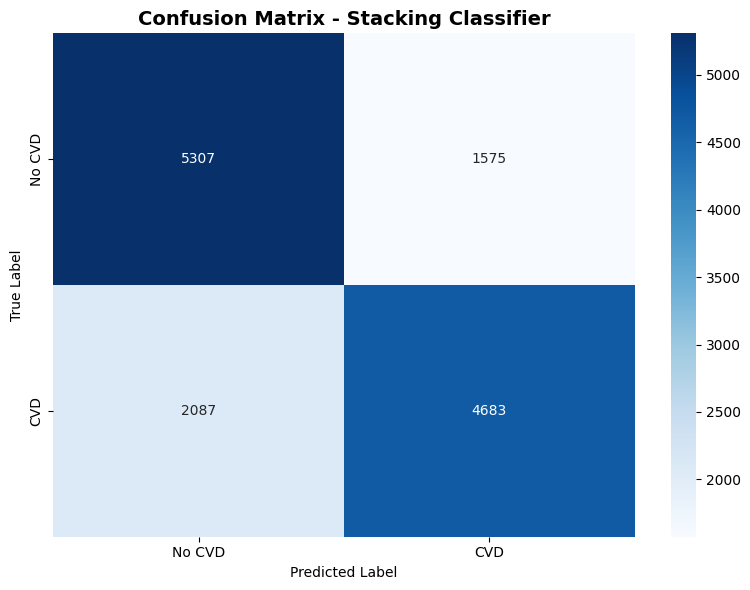


Additional Metrics:
Specificity (True Negative Rate): 0.7711
Negative Predictive Value (NPV):  0.7177
PR AUC:                           0.7796


In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No CVD', 'CVD'],
            yticklabels=['No CVD', 'CVD'])
plt.title('Confusion Matrix - Stacking Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
npv = tn / (tn + fn)

print(f"\nAdditional Metrics:")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"Negative Predictive Value (NPV):  {npv:.4f}")
print(f"PR AUC:                           {pr_auc:.4f}")

## 11. ROC Curve

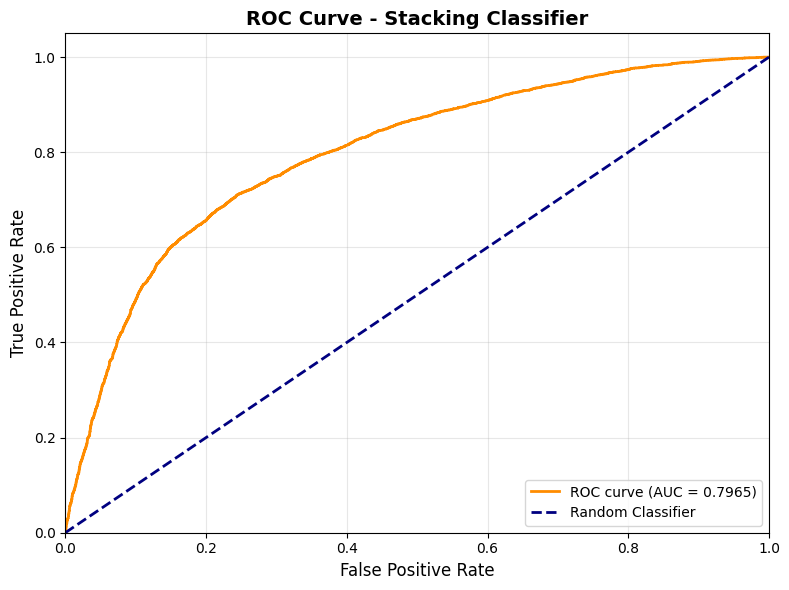

In [18]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Stacking Classifier', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Precision-Recall Curve

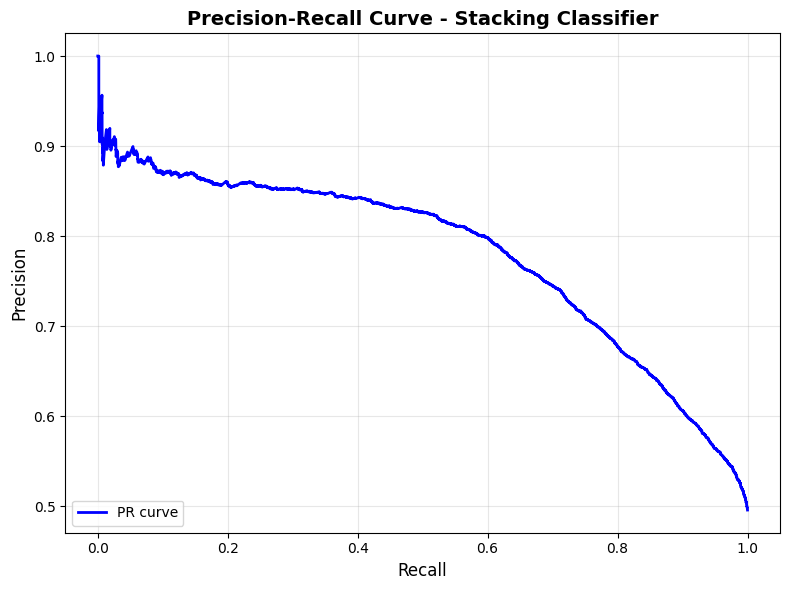

In [19]:
# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='PR curve')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Stacking Classifier', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Save Model and Results

In [ ]:
import joblib
import os

# Create directory for stacking models
os.makedirs('Stacking_Models', exist_ok=True)

# Save stacking classifier
joblib.dump(stacking_clf, 'Stacking_Models/stacking_classifier.joblib')
print("Stacking classifier saved to: Stacking_Models/stacking_classifier.joblib")

# Save scaler
joblib.dump(scaler, 'Stacking_Models/feature_scaler.joblib')
print("Feature scaler saved to: Stacking_Models/feature_scaler.joblib")

# Save results
results_df.to_csv('Stacking_Models/model_comparison_results.csv', index=False)
print("Results saved to: Stacking_Models/model_comparison_results.csv")

# Save detailed test set metrics as CSV
test_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC', 'Specificity', 'NPV'],
    'Value': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba),
        pr_auc,
        specificity,
        npv
    ]
})
test_metrics_df.to_csv('Stacking_Models/test_set_metrics.csv', index=False)
print("Test set metrics saved to: Stacking_Models/test_set_metrics.csv")

# Save detailed metrics
detailed_metrics = {
    'Test Accuracy': accuracy_score(y_test, y_test_pred),
    'Test Precision': precision_score(y_test, y_test_pred),
    'Test Recall': recall_score(y_test, y_test_pred),
    'Test F1 Score': f1_score(y_test, y_test_pred),
    'Test ROC AUC': roc_auc_score(y_test, y_test_proba),
    'Test PR AUC': pr_auc,
    'Test Specificity': specificity,
    'Test NPV': npv,
    'Training Samples': len(X_train),
    'Test Samples': len(X_test),
    'Number of Features': X_train.shape[1],
    'Number of Base Models': len(base_models),
    'CV Folds': 5
}

with open('Stacking_Models/stacking_metrics_summary.txt', 'w') as f:
    f.write("Stacking Classifier Performance Summary\n")
    f.write("="*50 + "\n\n")
    for key, value in detailed_metrics.items():
        f.write(f"{key}: {value}\n")
    f.write("\n" + "="*50 + "\n")
    f.write("\nClassification Report:\n")
    f.write(classification_report(y_test, y_test_pred, target_names=['No CVD', 'CVD']))

print("Detailed metrics saved to: Stacking_Models/stacking_metrics_summary.txt")
print("\nAll models and results saved successfully!")